In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("titanic_train - Copy (1).csv")

In [3]:
df.columns = df.columns.str.strip().str.lower()
print("Columns:\n", df.columns)
print("\nFirst 5 rows:")
print(df.head())

Columns:
 Index(['passenger_id', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch',
       'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest',
       'survived'],
      dtype='object')

First 5 rows:
   passenger_id  pclass                                               name  \
0          1216       3                                 Smyth, Miss. Julia   
1           699       3                                    Cacic, Mr. Luka   
2          1267       3  Van Impe, Mrs. Jean Baptiste (Rosalie Paula Go...   
3           449       2              Hocking, Mrs. Elizabeth (Eliza Needs)   
4           576       2                                    Veal, Mr. James   

      sex   age  sibsp  parch  ticket     fare cabin embarked boat  body  \
0  female   NaN      0      0  335432   7.7333   NaN        Q   13   NaN   
1    male  38.0      0      0  315089   8.6625   NaN        S  NaN   NaN   
2  female  30.0      1      1  345773  24.1500   NaN        S  NaN   NaN   
3  female  5

In [4]:
print("\nInfo:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   passenger_id  850 non-null    int64  
 1   pclass        850 non-null    int64  
 2   name          850 non-null    object 
 3   sex           850 non-null    object 
 4   age           676 non-null    float64
 5   sibsp         850 non-null    int64  
 6   parch         850 non-null    int64  
 7   ticket        850 non-null    object 
 8   fare          849 non-null    float64
 9   cabin         191 non-null    object 
 10  embarked      849 non-null    object 
 11  boat          308 non-null    object 
 12  body          73 non-null     float64
 13  home.dest     464 non-null    object 
 14  survived      850 non-null    int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 99.7+ KB
None

Missing Values:
passenger_id      0
pclass            0
name              0
sex         

In [5]:
if 'age' in df.columns:
    df['age'] = df['age'].fillna(df['age'].median())
if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
if 'fare' in df.columns:
    df['fare'] = df['fare'].fillna(df['fare'].median())
cols_to_drop = ['cabin', 'boat', 'body', 'home.dest']
df.drop([col for col in cols_to_drop if col in df.columns], axis=1, inplace=True)
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
passenger_id    0
pclass          0
name            0
sex             0
age             0
sibsp           0
parch           0
ticket          0
fare            0
embarked        0
survived        0
dtype: int64


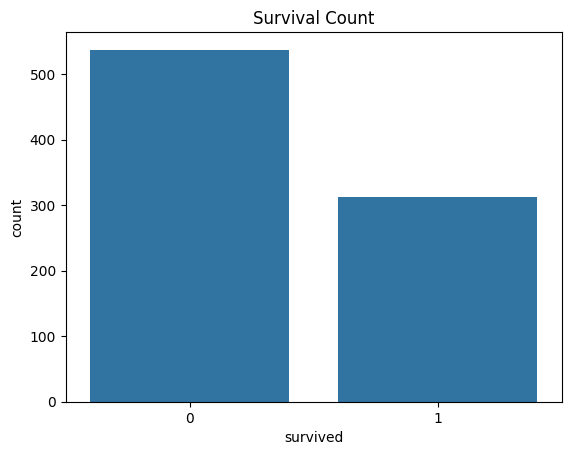

In [6]:
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

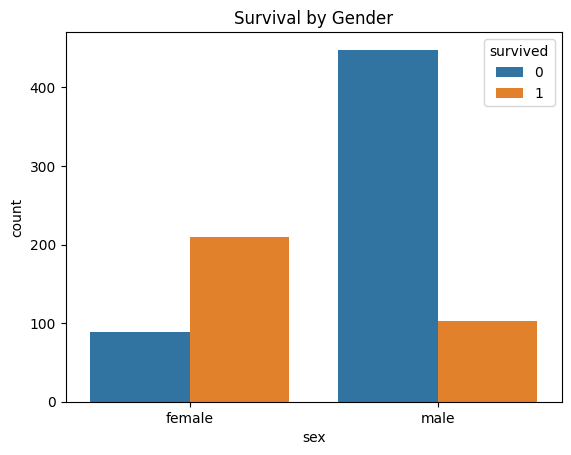

In [7]:
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival by Gender")
plt.show()

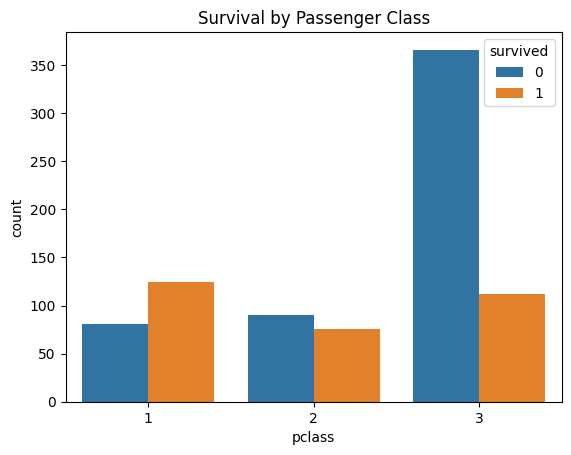

In [8]:
sns.countplot(x='pclass', hue='survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

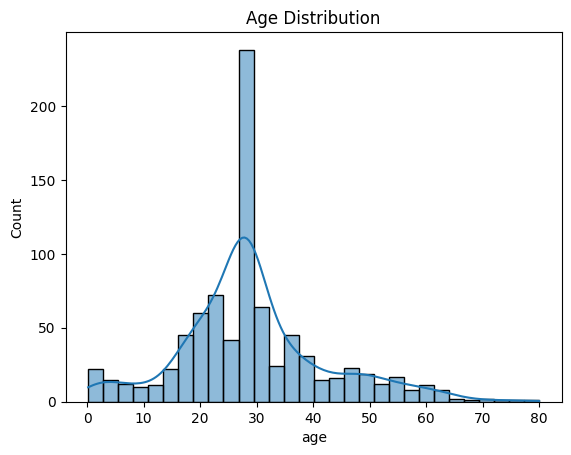

In [9]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

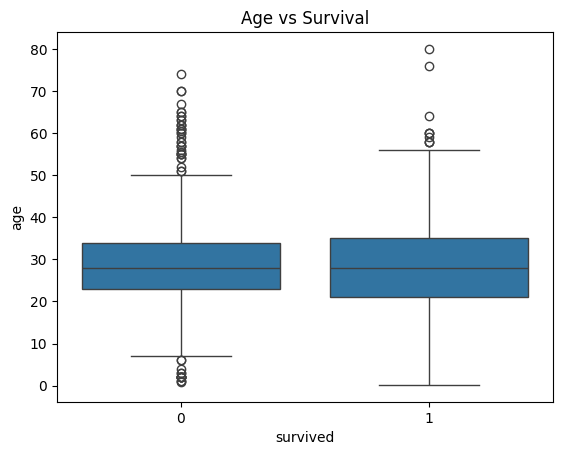

In [10]:
sns.boxplot(x='survived', y='age', data=df)
plt.title("Age vs Survival")
plt.show()

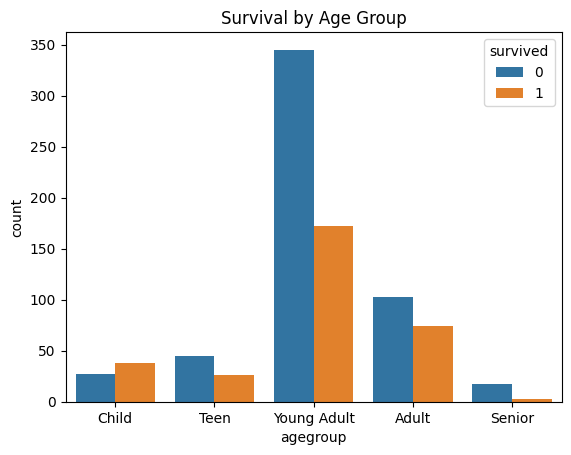

In [11]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['agegroup'] = pd.cut(df['age'], bins=bins, labels=labels)
sns.countplot(x='agegroup', hue='survived', data=df)
plt.title("Survival by Age Group")
plt.show()

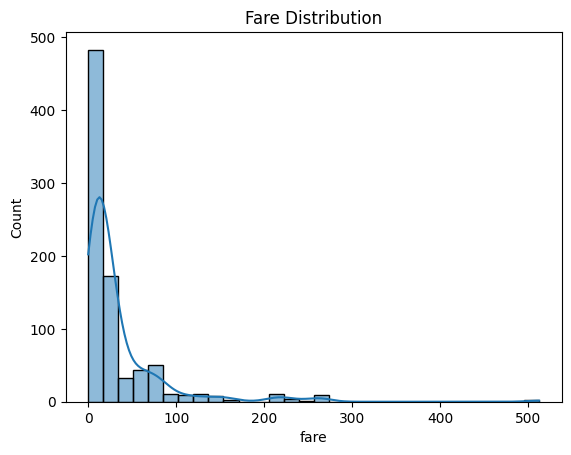

In [12]:
sns.histplot(df['fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

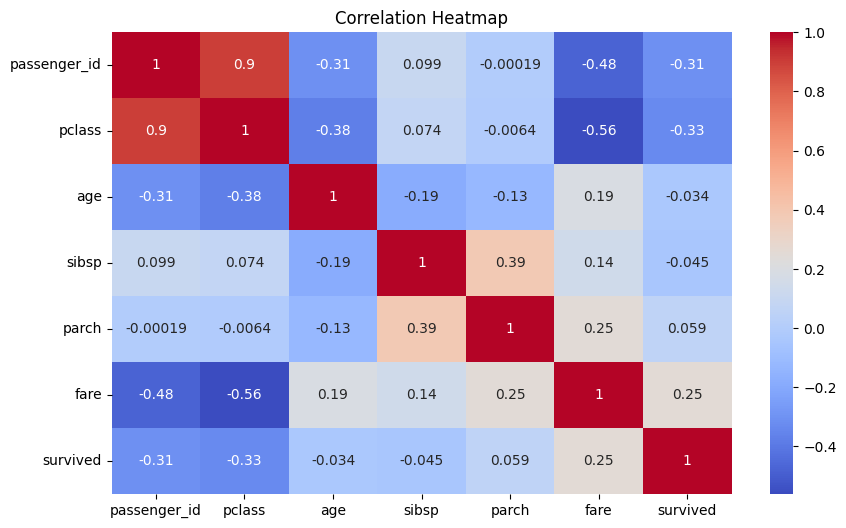

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()